In [22]:
%pip install datasets scikit-learn pandas --upgrade

Note: you may need to restart the kernel to use updated packages.


In [23]:

from datasets import load_dataset

# Load the MATH-500 dataset (high-quality 500 problems from MATH benchmark)
math500_dataset = load_dataset("HuggingFaceH4/MATH-500", split="test")
# Load the original competition MATH dataset for comparison
math_dataset = load_dataset("qwedsacf/competition_math", split="train")

In [24]:
# Split MATH-500 into train/test sets (80/20)
from sklearn.model_selection import train_test_split
import pandas as pd

# Convert MATH-500 to pandas for easier splitting
math500_df = pd.DataFrame(math500_dataset)

# Stratified split by subject to ensure balanced representation
math500_train_df, math500_test_df = train_test_split(
    math500_df, test_size=0.2, random_state=42, 
    stratify=math500_df['subject']
)

# Convert back to datasets format for consistency
from datasets import Dataset
math500_train = Dataset.from_pandas(math500_train_df)
math500_test = Dataset.from_pandas(math500_test_df)

# Original MATH dataset split
tts = math_dataset.train_test_split(test_size=0.2, seed=79)
math_test = tts['test']
math_train = tts['train']




In [25]:
print("MATH Competition Dataset:")
print(math_test)
print(math_train)
print("\nMATH-500 Dataset:")
print(math500_test)
print(math500_train)
print(f"\nMATH-500 Subjects: {sorted(math500_df['subject'].unique())}")
print(f"MATH-500 Difficulty Levels: {sorted(math500_df['level'].unique())}")

MATH Competition Dataset:
Dataset({
    features: ['problem', 'level', 'type', 'solution'],
    num_rows: 2500
})
Dataset({
    features: ['problem', 'level', 'type', 'solution'],
    num_rows: 10000
})

MATH-500 Dataset:
Dataset({
    features: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id', '__index_level_0__'],
    num_rows: 100
})
Dataset({
    features: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id', '__index_level_0__'],
    num_rows: 400
})

MATH-500 Subjects: ['Algebra', 'Counting & Probability', 'Geometry', 'Intermediate Algebra', 'Number Theory', 'Prealgebra', 'Precalculus']
MATH-500 Difficulty Levels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


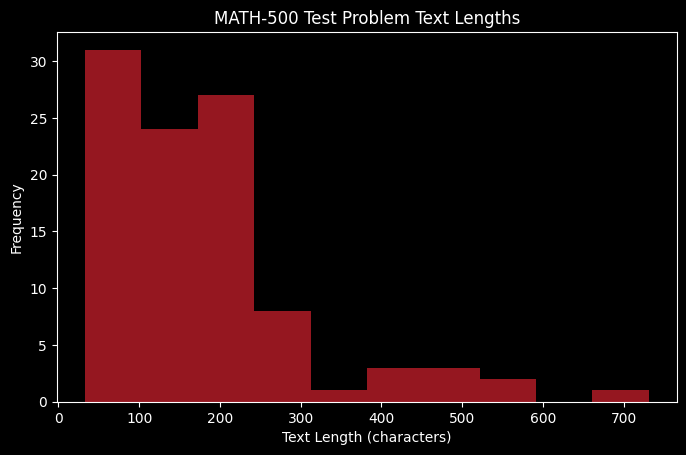

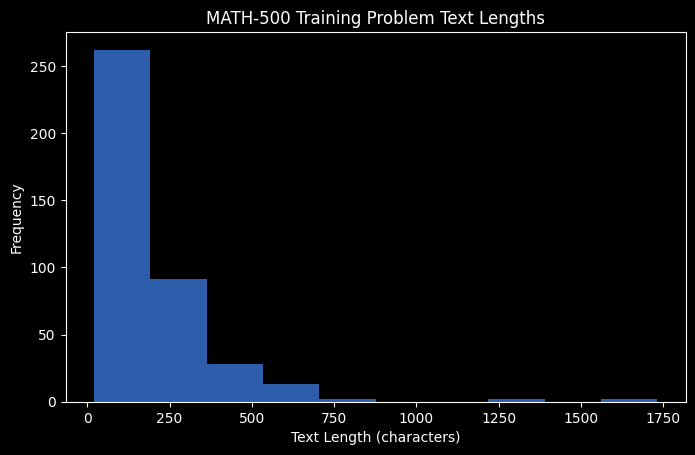

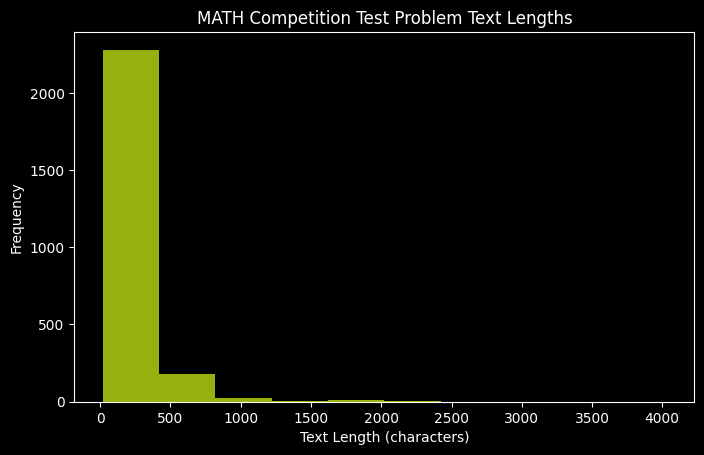

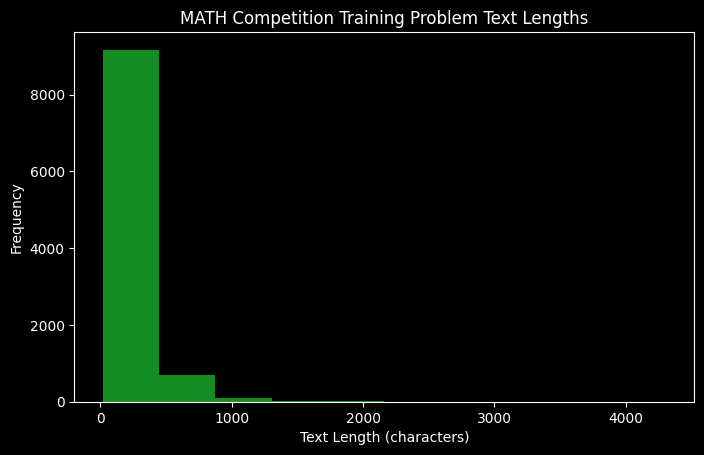

In [26]:
import matplotlib.pyplot as plt

# Calculate problem lengths for all datasets
math500_test_problem_lengths = []
math500_train_problem_lengths = []
math_test_problem_lengths = []
math_train_problem_lengths = []

# Get lengths of MATH-500 problems
for i in range(0, len(math500_test['problem'])):
    math500_test_problem_lengths.append(len(math500_test['problem'][i]))
for i in range(0, len(math500_train['problem'])):
    math500_train_problem_lengths.append(len(math500_train['problem'][i]))

# Get lengths of original MATH dataset
for i in range(0, len(math_test['problem'])):
    math_test_problem_lengths.append(len(math_test['problem'][i]))
for i in range(0, len(math_train['problem'])):
    math_train_problem_lengths.append(len(math_train['problem'][i]))

# MATH-500 Test Lengths
plt.figure(figsize=(8, 4.8))
plt.hist(math500_test_problem_lengths, bins=10, alpha=0.7, color='#d6222e')
plt.title('MATH-500 Test Problem Text Lengths')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.show()

# MATH-500 Training lengths
plt.figure(figsize=(8, 4.8))
plt.hist(math500_train_problem_lengths, bins=10, alpha=0.7, color='#4287f5')
plt.title('MATH-500 Training Problem Text Lengths')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.show()

# Original MATH Test Lengths
plt.figure(figsize=(8, 4.8))
plt.hist(math_test_problem_lengths, bins=10, alpha=0.7, color='#dafc14')
plt.title('MATH Competition Test Problem Text Lengths')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.show()

# Original MATH Training lengths
plt.figure(figsize=(8, 4.8))
plt.hist(math_train_problem_lengths, bins=10, alpha=0.7, color='#1dcc34')
plt.title('MATH Competition Training Problem Text Lengths')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.show()

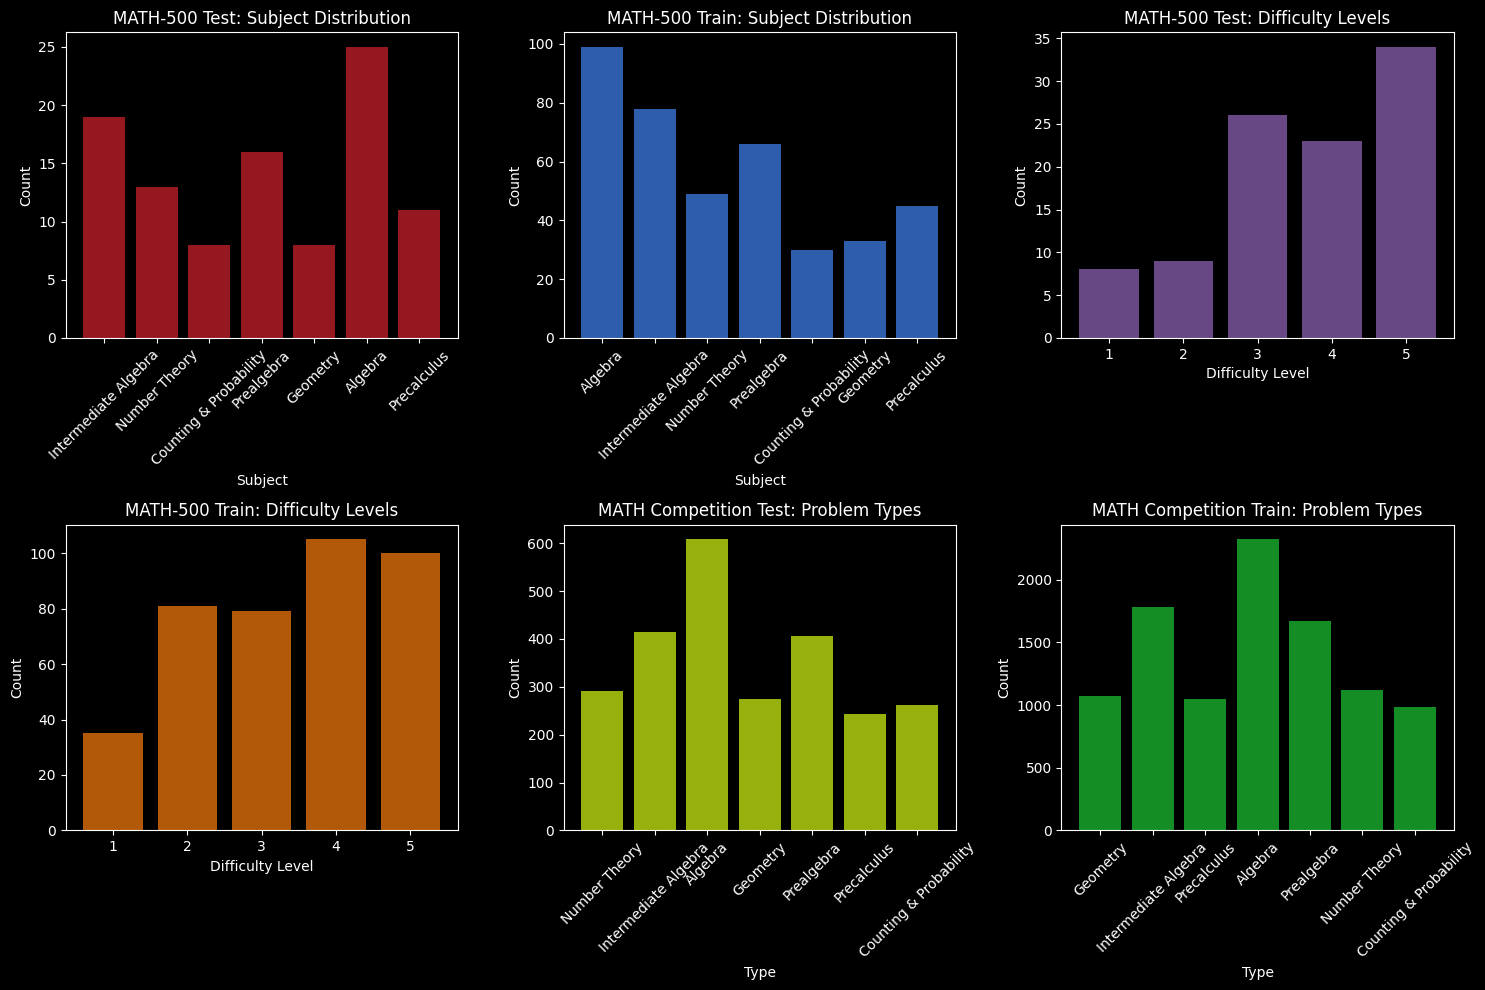

✅ Analysis includes:
- MATH-500: High-quality 500 problems with subject and difficulty level metadata
- MATH Competition: Original large-scale dataset for comparison
- Both datasets provide comprehensive math problem coverage


In [27]:
from collections import Counter

# Analyze MATH-500 subjects distribution
math500_test_subjects = Counter(math500_test["subject"])
math500_train_subjects = Counter(math500_train["subject"])

# Analyze MATH-500 difficulty levels
math500_test_levels = Counter(math500_test["level"])
math500_train_levels = Counter(math500_train["level"])

# Original MATH dataset types
math_test_types = Counter(math_test["type"]) if "type" in math_test.features else Counter()
math_train_types = Counter(math_train["type"]) if "type" in math_train.features else Counter()

# Create comprehensive visualization
plt.figure(figsize=(15, 10))

# MATH-500 Subject Distribution
plt.subplot(2, 3, 1)
subjects = list(math500_test_subjects.keys())
subject_counts = list(math500_test_subjects.values())
plt.bar(subjects, subject_counts, color='#d6222e', alpha=0.7)
plt.title('MATH-500 Test: Subject Distribution')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(2, 3, 2)
subjects = list(math500_train_subjects.keys())
subject_counts = list(math500_train_subjects.values())
plt.bar(subjects, subject_counts, color='#4287f5', alpha=0.7)
plt.title('MATH-500 Train: Subject Distribution')
plt.xlabel('Subject')
plt.ylabel('Count')
plt.xticks(rotation=45)

# MATH-500 Difficulty Level Distribution
plt.subplot(2, 3, 3)
levels = list(math500_test_levels.keys())
level_counts = list(math500_test_levels.values())
plt.bar(levels, level_counts, color='#9467bd', alpha=0.7)
plt.title('MATH-500 Test: Difficulty Levels')
plt.xlabel('Difficulty Level')
plt.ylabel('Count')

plt.subplot(2, 3, 4)
levels = list(math500_train_levels.keys())
level_counts = list(math500_train_levels.values())
plt.bar(levels, level_counts, color='#ff7f0e', alpha=0.7)
plt.title('MATH-500 Train: Difficulty Levels')
plt.xlabel('Difficulty Level')
plt.ylabel('Count')

# Original MATH dataset types (if available)
if math_test_types:
    plt.subplot(2, 3, 5)
    types = list(math_test_types.keys())
    type_counts = list(math_test_types.values())
    plt.bar(types, type_counts, color='#dafc14', alpha=0.7)
    plt.title('MATH Competition Test: Problem Types')
    plt.xlabel('Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45)

if math_train_types:
    plt.subplot(2, 3, 6)
    types = list(math_train_types.keys())
    type_counts = list(math_train_types.values())
    plt.bar(types, type_counts, color='#1dcc34', alpha=0.7)
    plt.title('MATH Competition Train: Problem Types')
    plt.xlabel('Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("✅ Analysis includes:")
print("- MATH-500: High-quality 500 problems with subject and difficulty level metadata")
print("- MATH Competition: Original large-scale dataset for comparison")
print("- Both datasets provide comprehensive math problem coverage")

In [28]:
# Save as CSV using Python's built-in csv module (bypasses pandas issues)
import csv
import os

print("💾 Saving MATH-500 dataset as CSV...")

try:
    # Convert datasets to list of dictionaries
    train_data = list(math500_train)
    test_data = list(math500_test)
    
    # Create Dataset directory if it doesn't exist
    os.makedirs("Dataset", exist_ok=True)
    
    # Save training set as CSV
    with open("Dataset/math500_train.csv", "w", newline="", encoding="utf-8") as f:
        if train_data:
            fieldnames = train_data[0].keys()
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(train_data)
    
    # Save test set as CSV
    with open("Dataset/math500_test.csv", "w", newline="", encoding="utf-8") as f:
        if test_data:
            fieldnames = test_data[0].keys()
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(test_data)
    
    print("✅ CSV files saved successfully!")
    print(f"📊 Train set: {len(train_data)} samples")
    print(f"📊 Test set: {len(test_data)} samples")
    print("📝 Files saved:")
    print("   - Dataset/math500_train.csv")
    print("   - Dataset/math500_test.csv")
    
    # Show sample of what was saved
    if train_data:
        print(f"\n📋 Columns: {list(train_data[0].keys())}")
        print(f"📋 Sample problem: {train_data[0]['problem'][:100]}...")
    
except Exception as e:
    print(f"❌ CSV saving failed: {e}")
    print("📝 Data remains available in memory: math500_train, math500_test")


💾 Saving MATH-500 dataset as CSV...
✅ CSV files saved successfully!
📊 Train set: 400 samples
📊 Test set: 100 samples
📝 Files saved:
   - Dataset/math500_train.csv
   - Dataset/math500_test.csv

📋 Columns: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id', '__index_level_0__']
📋 Sample problem: For what values of $x$ is it true that $x^2 - 5x - 4 \le 10$? Express your answer in interval notati...
